# Exploratory Data Analysis (EDA) untuk Proyek Penjualan Motor
Proses EDA dilakukan untuk mengeksplorasi data dan mencari tau informasi dan visualisasi apa saja yang nantinya akan di tampilkan dalam dashboard ataupun laporan analisis. Tujuan utama dari EDA ini adalah untuk menjawab pertanyaan-pertanyaan berikut yang akan menjadi dasar dashboad dan laporan analisis:

- Metrik Utama (KPI) apa yang paling penting?
- Bagaimana tren penjualan seiring waktu?
- Siapa/Apa kontributor terbesar (produk, cabang)?
- Bagaimana karakteristik dan preferensi pelanggan?

## A. Persiapan
Sebelum memulai proses EDA, pertama-tama perlu menyiapkan environment Python dan Dataset yang akan digunakan.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Muat data dari BigQuery
from google.colab import auth
auth.authenticate_user()

project_id = "portfolio-sales-motorcycle"
sql_query = """
SELECT
  *
FROM
  `portfolio-sales-motorcycle.sales_motor_data.v_final_sales`
"""

In [ ]:
# Muat hasilnya ke dalam DataFrame pandas
df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')

## B. Inspeksi Awal & Statistik Deskriptif
Tujuan tahap ini adalah untuk mendapatkan gambaran umum dari dataset yang akan digunakan.

### 1.1. Validasi Struktur Data
Pertama-tama perlu memastikan data termuat dengan benar, tipe data sesuai, dan melihat apakah ada data kosong yang terlewat.

In [ ]:
print("\n5 baris pertama dari data:")
print(df.head())
print("\nInformasi Data:")
df.info()


5 baris pertama dari data:
          order_id             branch        province    product payment  \
0  BTDTTU220500042   CB TERNATE UTARA    MALUKU UTARA     SCOOPY  CREDIT   
1  BTDKKS220400028  CB KEPULAUAN SULA    MALUKU UTARA  VARIO 160  CREDIT   
2  BTDSMG220500008        CB SEMARANG     JAWA TENGAH       REVO    CASH   
3  BTDMMS220500010          CB MAMASA  SULAWESI BARAT       BEAT  CREDIT   
4  BTDMMJ220400053          CB MAMUJU  SULAWESI BARAT     SCOOPY    CASH   

   process  order_date   sale_date  discount   revenue  
0  OFFLINE  2022-05-24  2022-05-29         0  23150000  
1  OFFLINE         NaT  2022-05-04         0  30235000  
2  OFFLINE  2022-05-04  2022-05-04       800  17479200  
3   ONLINE  2022-05-28  2022-05-29         0  19380000  
4   ONLINE         NaT  2022-05-04        20  23119980  

Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10493 entries, 0 to 10492
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  --

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['sale_date'] = pd.to_datetime(df['sale_date'])

### 1.2. Statistik Deskriptif
Setelah mengetahui bentuk dan kondisi data, selanjutnya dilakukan analisis Statistik Deskriptif dengan tujuan untuk mengetahui nilai rata-rata, min, max, dan sebaran data dan mengetahui kategori mana yang paling sering muncul.

In [ ]:
df.describe()

,discount,revenue
count,4621.0,4621.0
mean,30989.840727,23671643.806103
std,211638.634495,5467715.795848
min,0.0,14469900.0
25%,0.0,19665000.0
50%,0.0,22720000.0
75%,0.0,26800000.0
max,3000000.0,86460000.0


In [ ]:
df.describe(include='object')

,order_id,branch,province,product,payment,process
count,10493,10493,10493,10493,10493,10493
unique,10493,406,29,19,2,2
top,BTDBTL220500092,CB SEMARANG,JAWA TENGAH,BEAT,CREDIT,OFFLINE
freq,1,298,3060,3252,9391,9369


## C. Analisis Univariat (Analisis per Variabel)
Fokus pada pemahaman distribusi dan karakteristik setiap variabel penting secara individual.

### 2.1. Analisis Variabel Kategorikal

Tahap ini dimaksud untuk mendapatkan frekuensi atau jumlah dari setiap kategori. Selain itu, tahap ini juga untuk menjawab beberapa pertanyaan dasar, anatara lain seperti berikut:
- Produk apa yang paling banyak dipesan?
- Metode pembayaran apa yang paling populer?
- Cabang mana yang menerima pesanan terbanyak?

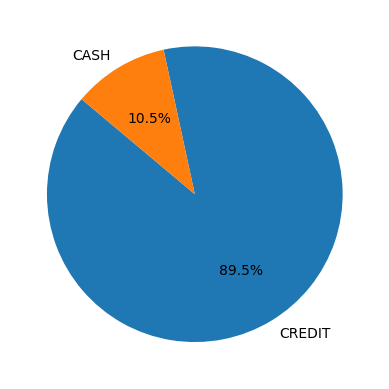

,count
payment,
CREDIT,9391
CASH,1102


In [ ]:
payment_order = df['payment'].value_counts()
plt.pie(payment_order, labels=payment_order.index, autopct='%1.1f%%', startangle=140)
plt.show()

payment_order

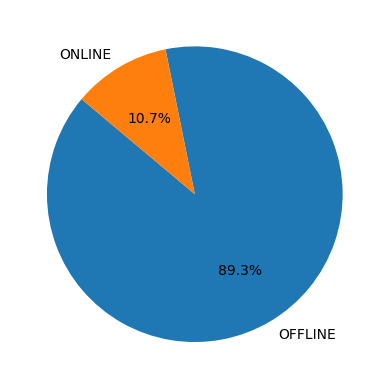

,count
process,
OFFLINE,9369
ONLINE,1124


In [ ]:
process_order = df['process'].value_counts()
plt.pie(process_order, labels=process_order.index, autopct='%1.1f%%', startangle=140)
plt.show()

process_order

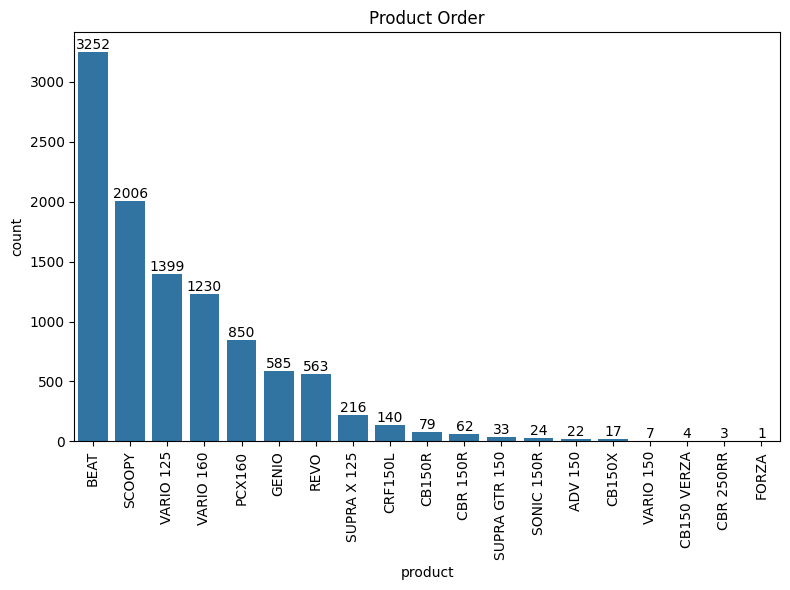

In [ ]:
plt.figure(figsize=(8, 6))
product_order = df['product'].value_counts().index

axp = sns.countplot(x='product', data=df, order=product_order)
for p in axp.patches:
    axp.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Product Order')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

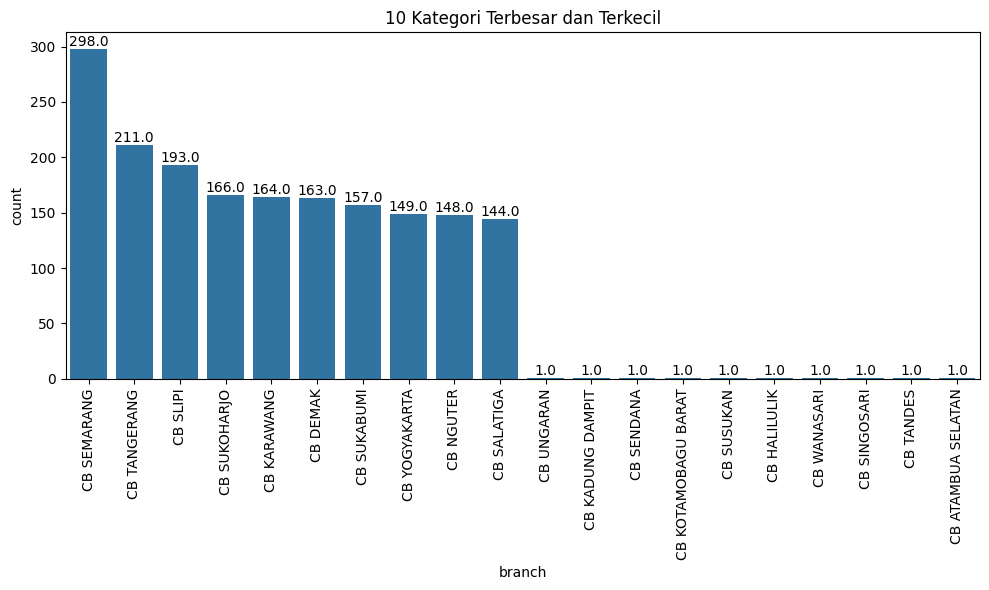

In [ ]:
branch_order = df['branch'].value_counts()

top10 = branch_order.head(10)
bottom10 = branch_order.tail(10)
selected_branch = pd.concat([top10, bottom10])
df_filtered = df[df['branch'].isin(selected_branch.index)]

# Buat countplot
plt.figure(figsize=(10, 6))
axb = sns.countplot(x='branch', data=df_filtered, order=selected_branch.index)

# Tambahkan label jumlah di atas batang
for p in axb.patches:
    height = p.get_height()
    axb.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.title('10 Kategori Terbesar dan Terkecil')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.2. Analisis Variabel Numerik
Tahap ini dilakukan untuk mencari distribusi, sebaran, dan adanya outlier (nilai ekstrem). Menggunakan Histogram dan Box Plot pada revenue untuk menjawab beberapa pertanyaan, misalnya:
- Bagaimana sebaran revenue per transaksi?
- Apakah sebagian besar transaksi bernilai kecil atau besar?

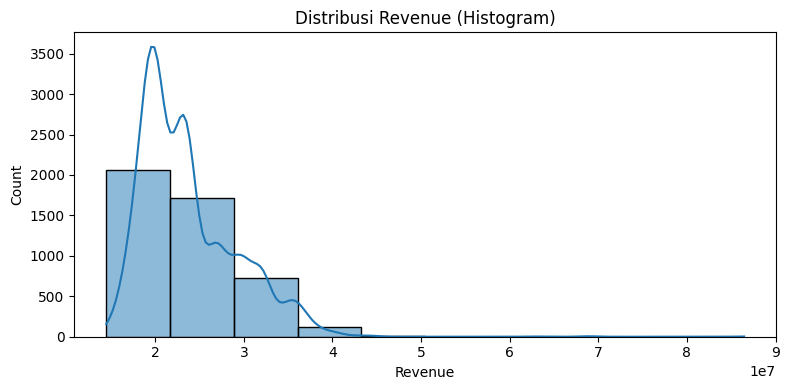

In [ ]:
# Visualisasi distribusi data dengan histogram
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='revenue', bins=10, kde=True)
plt.title('Distribusi Revenue (Histogram)')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

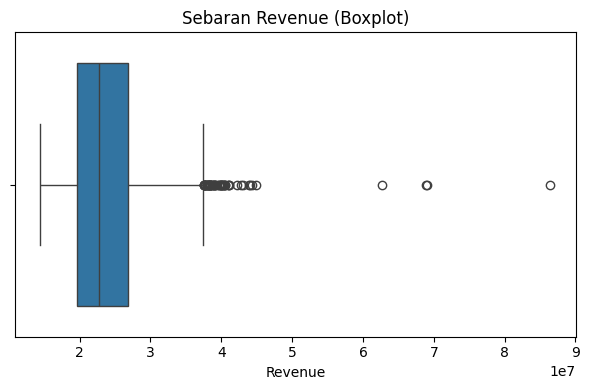

In [ ]:
# Visualisasi sebaran data dengan boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='revenue')
plt.title('Sebaran Revenue (Boxplot)')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

### 2.3. Analisis Variabel Waktu

Tahap ini dimaksudkan untuk melihat tren dan pola berdasarkan waktu (harian, mingguan) serta menjawab beberapa pertanyaan, seperti:
- Bagaimana tren jumlah pesanan harian selama bulan Mei?
- Apakah ada pola mingguan?

<Axes: xlabel='order_date'>

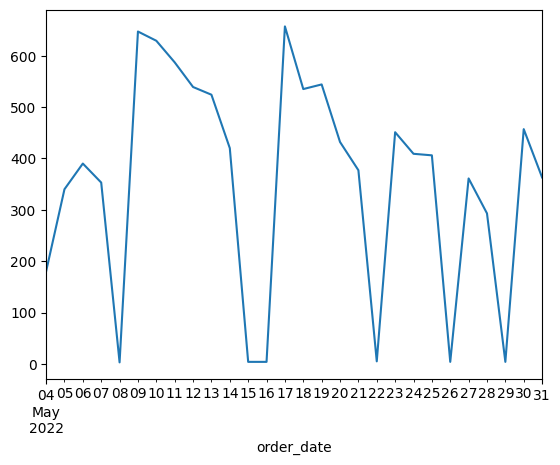

In [ ]:
df.set_index('order_date').resample('D')['order_id'].count().plot()

<Axes: xlabel='sale_date'>

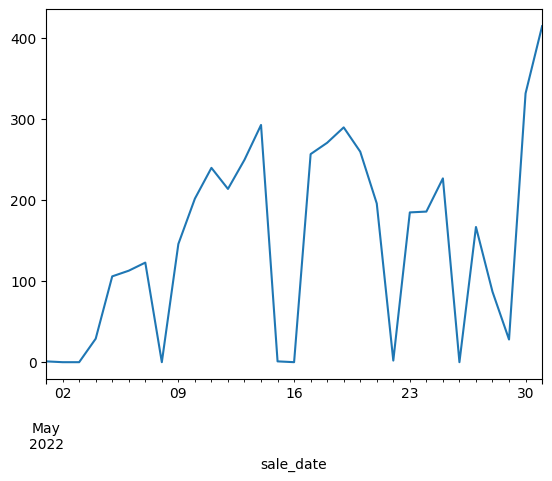

In [ ]:
df.set_index('sale_date').resample('D')['order_id'].count().plot()

<Axes: xlabel='sale_date'>

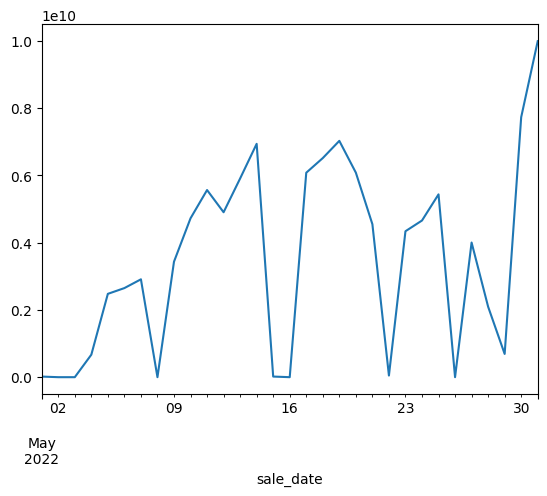

In [ ]:
df.set_index('sale_date').resample('D')['revenue'].sum().plot()

## D. Analisis Bivariat (Mencari Hubungan Antar Variabel)
Ini adalah inti dari EDA, di mana mulai menghubungkan titik-titik dan menemukan insight yang lebih dalam.

### 3.1. Hubungan Numerik dengan Kategorikal

Pada tahap ini akan dicari kategori mana yang menghasilkan pendapatan paling besar dan paling profitable.

In [ ]:
df.groupby('product')['revenue'].sum().sort_values(ascending=False)

,revenue
product,
VARIO 160,22496910092
BEAT,21287680073
VARIO 125,13971554699
SCOOPY,13065314380
PCX160,11389305501
REVO,8397619601
GENIO,6399802003
SUPRA X 125,3825993206
CBR 150R,2000737267


In [ ]:
df.groupby('branch')['revenue'].sum().sort_values(ascending=False)

,revenue
branch,
CB SEMARANG,2683627688
CB SALATIGA,1837403395
CB KARAWANG,1816122175
CB TERNATE,1757009450
CB DEMAK,1681358348
...,...
CB TALAGASARI,0
CB BENER,0
CB BATU CEPER,0


### 3.2. Hubungan Kategorikan dengan

Melihat hubungan atau preferensi antar kategori.
- Apakah ada produk tertentu yang cenderung dibeli dengan metode pembayaran CASH?
- Apakah kanal ONLINE lebih populer di provinsi tertentu?

In [ ]:
pd.crosstab(df['product'], df['payment'])

payment,CASH,CREDIT
product,,
ADV 150,10,12
BEAT,146,3106
CB150 VERZA,1,3
CB150R,25,54
CB150X,5,12
CBR 150R,19,43
CBR 250RR,3,0
CRF150L,24,116
FORZA,0,1


In [ ]:
pd.crosstab(df['product'], df['process'])

process,OFFLINE,ONLINE
product,,
ADV 150,21,1
BEAT,2849,403
CB150 VERZA,4,0
CB150R,75,4
CB150X,15,2
CBR 150R,56,6
CBR 250RR,3,0
CRF150L,125,15
FORZA,1,0


----------------------------------------------------------------------------------

# Analisis Statistik Lanjutan

## Uji-t


Analisis 1: Apakah Pelanggan Tunai Lebih Menguntungkan? (Uji-t)

ATV (Rata-rata Transaksi) untuk CASH: Rp 25,117,564.45
ATV (Rata-rata Transaksi) untuk CREDIT: Rp 23,418,276.73
P-value dari Uji-t: 4.452714663887648e-14

Kesimpulan: Terdapat perbedaan yang signifikan secara statistik antara ATV pembayaran CASH dan CREDIT.


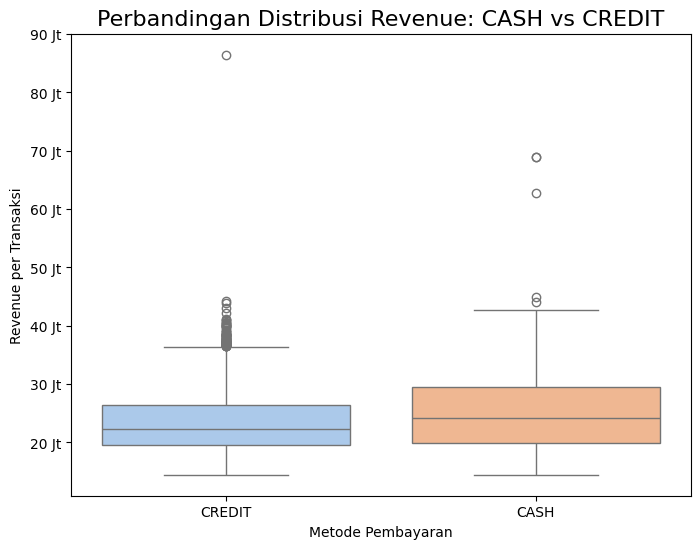

--------------------------------------------------


In [ ]:
# 2. Analisis Perbandingan Pembayaran (Uji-t)
print("\nAnalisis 1: Apakah Pelanggan Tunai Lebih Menguntungkan? (Uji-t)\n")

# Menyiapkan data untuk Uji-t
payment_analysis_df = df.dropna(subset=['payment', 'revenue'])
cash_payments = payment_analysis_df[payment_analysis_df['payment'] == 'CASH']['revenue']
credit_payments = payment_analysis_df[payment_analysis_df['payment'] == 'CREDIT']['revenue']

# Melakukan Uji-t (Independent Samples t-test)
t_stat, p_value = ttest_ind(cash_payments, credit_payments, nan_policy='omit')

# Menghitung Nilai Transaksi Rata-Rata (ATV)
atv_cash = cash_payments.mean()
atv_credit = credit_payments.mean()

print(f"ATV (Rata-rata Transaksi) untuk CASH: Rp {atv_cash:,.2f}")
print(f"ATV (Rata-rata Transaksi) untuk CREDIT: Rp {atv_credit:,.2f}")
print(f"P-value dari Uji-t: {p_value}")

if p_value < 0.05:
    print("\nKesimpulan: Terdapat perbedaan yang signifikan secara statistik antara ATV pembayaran CASH dan CREDIT.")
else:
    print("\nKesimpulan: Tidak terdapat perbedaan yang signifikan secara statistik antara ATV pembayaran CASH dan CREDIT.")

# Visualisasi perbandingan
plt.figure(figsize=(8, 6))
sns.boxplot(data=payment_analysis_df, x='payment', y='revenue', palette='pastel')
plt.title('Perbandingan Distribusi Revenue: CASH vs CREDIT', fontsize=16)
plt.xlabel('Metode Pembayaran')
plt.ylabel('Revenue per Transaksi')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f} Jt'))
plt.show()
print("-" * 50)

## Clustering


Analisis 3: Bagaimana Mengelompokkan Cabang Berdasarkan Kinerja?



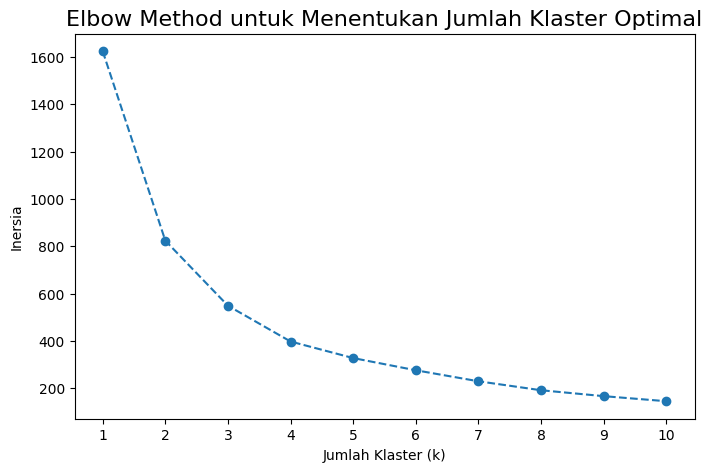

Berdasarkan Elbow Method, jumlah klaster optimal yang dipilih adalah 4.

Rata-rata Karakteristik per Klaster:
   cluster  order_count  sales_count      total_revenue  conversion_rate
0        0    15.650206     3.979424    95870698.353909        24.685127
1        1   144.882353    59.176471  1436514995.647059        46.332469
2        2    10.505882     8.117647   186610575.176471        82.235890
3        3    54.655738    32.098361   750941516.590164        65.850805


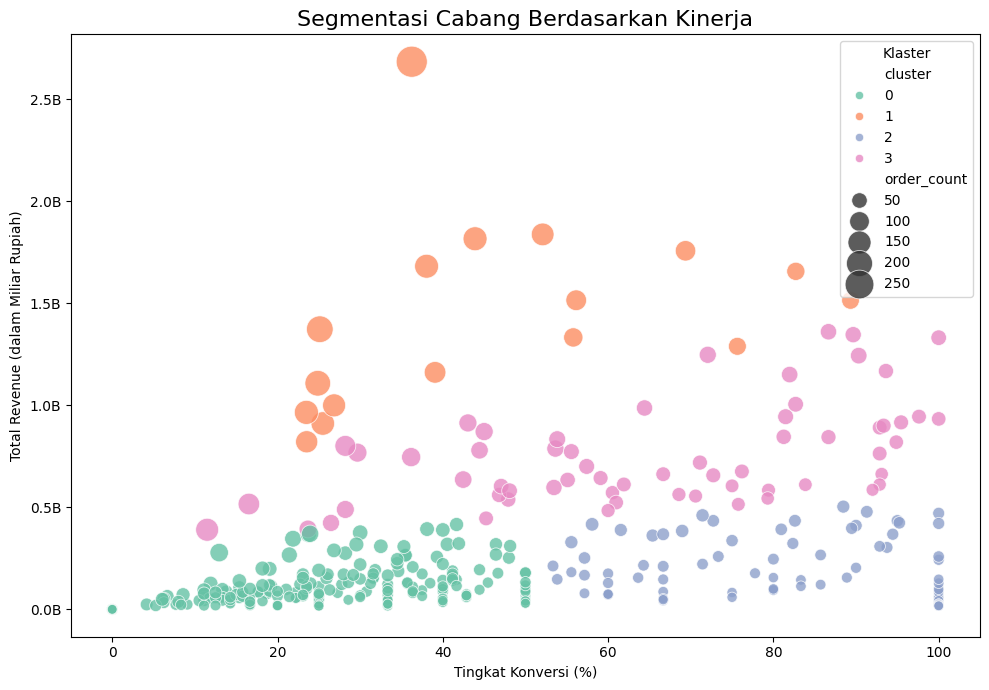

--------------------------------------------------


In [ ]:
# 3. Analisis Klaster (Segmentasi Cabang)
print("\nAnalisis 3: Bagaimana Mengelompokkan Cabang Berdasarkan Kinerja?\n")

# Agregasi data per cabang
branch_performance = df.groupby('branch').agg(
    order_count=('order_id', 'nunique'),
    sales_count=('sale_date', 'count'),
    total_revenue=('revenue', 'sum'),
    average_discount=('discount', 'mean')
).reset_index()

# Menghitung tingkat konversi
branch_performance['conversion_rate'] = (branch_performance['sales_count'] / branch_performance['order_count']) * 100
branch_performance.fillna(0, inplace=True) # Mengisi NaN jika ada cabang tanpa order/sales

# Memilih fitur untuk clustering
cluster_features = ['order_count', 'sales_count', 'total_revenue', 'conversion_rate']
X_cluster = branch_performance[cluster_features]

# Menormalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Menentukan jumlah cluster optimal dengan Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inersia')
plt.title('Elbow Method untuk Menentukan Jumlah Klaster Optimal', fontsize=16)
plt.xticks(range(1, 11))
plt.show()

# Berdasarkan grafik, kita pilih k=4.
optimal_k = 4
print(f"Berdasarkan Elbow Method, jumlah klaster optimal yang dipilih adalah {optimal_k}.\n")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
branch_performance['cluster'] = kmeans.fit_predict(X_scaled)

# Menganalisis hasil cluster
cluster_summary = branch_performance.groupby('cluster')[cluster_features].mean().reset_index()
print("Rata-rata Karakteristik per Klaster:")
print(cluster_summary)

# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=branch_performance,
    x='conversion_rate',
    y='total_revenue',
    hue='cluster',
    size='order_count',
    sizes=(50, 500),
    palette='Set2',
    alpha=0.8
)
plt.title('Segmentasi Cabang Berdasarkan Kinerja', fontsize=16)
plt.xlabel('Tingkat Konversi (%)')
plt.ylabel('Total Revenue (dalam Miliar Rupiah)')
plt.legend(title='Klaster')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.show()
print("-" * 50)

## Scaterplot

Jumlah transaksi dengan diskon (discount > 0): 613


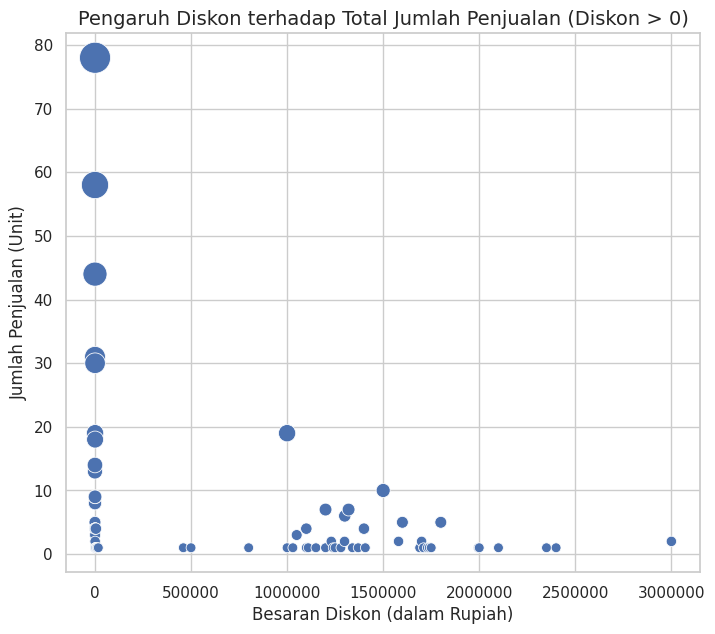

In [ ]:
# Langkah 1: Filter data untuk hanya menyertakan transaksi yang memiliki data penjualan (sales)
sales_df = df.dropna(subset=['revenue', 'discount'])

# LANGKAH 2 (BARU): Sisihkan data transaksi yang tidak memiliki diskon
sales_with_discount_df = sales_df[sales_df['discount'] > 0].copy()

# Cek berapa banyak transaksi dengan diskon yang akan kita analisis
print(f"Jumlah transaksi dengan diskon (discount > 0): {len(sales_with_discount_df)}")

# Langkah 3: Agregasi data berdasarkan nilai diskon
discount_analysis_df = sales_with_discount_df.groupby('discount').agg(
    sales_count=('revenue', 'count'),
    total_revenue=('revenue', 'sum')
).reset_index()

# Langkah 4: Visualisasi hasil agregasi
sns.set(style="whitegrid")
plt.figure(figsize=(18, 7))

# Plot 1: Pengaruh Diskon terhadap Jumlah Penjualan
plt.subplot(1, 2, 1)
sns.scatterplot(data=discount_analysis_df, x='discount', y='sales_count', size='sales_count', sizes=(50, 500), legend=False)
plt.title('Pengaruh Diskon terhadap Total Jumlah Penjualan (Diskon > 0)', fontsize=14)
plt.xlabel('Besaran Diskon (dalam Rupiah)')
plt.ylabel('Jumlah Penjualan (Unit)')
plt.ticklabel_format(style='plain', axis='x')

plt.show()

In [ ]:
# Langkah 1: Persiapan Data (Sama seperti sebelumnya)
# Filter data penjualan yang valid dan hanya yang memiliki diskon
sales_df = df.dropna(subset=['revenue', 'discount'])
sales_with_discount_df = sales_df[sales_df['discount'] > 0].copy()

# Agregasi data berdasarkan nilai diskon
discount_analysis_df = sales_with_discount_df.groupby('discount').agg(
    sales_count=('revenue', 'count'),
    total_revenue=('revenue', 'sum')
).reset_index()

print("Data Agregat yang Digunakan untuk Uji Hipotesis:")
print(discount_analysis_df)

# Cek apakah data cukup untuk dilakukan uji korelasi
if len(discount_analysis_df) < 3:
    print("\nData tidak cukup untuk melakukan uji hipotesis korelasi yang valid.")
else:
    # --- Langkah 2: Lakukan Uji Hipotesis Korelasi Pearson ---

    # Tentukan variabel yang akan diuji
    x = discount_analysis_df['discount']
    y = discount_analysis_df['sales_count']

    # Lakukan uji korelasi
    correlation_coefficient, p_value = pearsonr(x, y)


    # --- Langkah 3: Interpretasikan Hasil ---

    print(f"\n--- Hasil Uji Hipotesis Korelasi ---")
    print(f"Koefisien Korelasi (r): {correlation_coefficient:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Menentukan tingkat signifikansi (alpha)
    alpha = 0.05

    print(f"\nTingkat Signifikansi (alpha): {alpha}")
    print("Hipotesis Nol (H₀): Tidak ada korelasi signifikan antara diskon dan jumlah penjualan.")
    print("Hipotesis Alternatif (H₁): Terdapat korelasi signifikan antara diskon dan jumlah penjualan.")


    # Menarik kesimpulan berdasarkan p-value
    print("\n--- Kesimpulan Statistik ---")
    if p_value < alpha:
        print(f"Karena p-value ({p_value:.4f}) lebih kecil dari {alpha}, kita MENOLAK Hipotesis Nol.")
        print("Kesimpulan: Terdapat bukti statistik yang cukup untuk menyatakan bahwa ada hubungan yang signifikan antara besaran diskon dan jumlah penjualan.")
    else:
        print(f"Karena p-value ({p_value:.4f}) lebih besar dari {alpha}, kita GAGAL MENOLAK Hipotesis Nol.")
        print("Kesimpulan: Tidak ada bukti statistik yang cukup untuk menyatakan bahwa ada hubungan yang signifikan antara besaran diskon dan jumlah penjualan.")
        print("Hubungan yang mungkin terlihat pada scatter plot kemungkinan besar hanya bersifat kebetulan.")


Data Agregat yang Digunakan untuk Uji Hipotesis:
     discount  sales_count  total_revenue
0           1            1       18789999
1           4            2       37637992
2           6            1       29005994
3          10            1       25279990
4          17            1       26016983
..        ...          ...            ...
151   2000000            1       22480000
152   2100000            1       25556000
153   2350000            1       33165000
154   2400000            1       30117000
155   3000000            2      131580000

[156 rows x 3 columns]

--- Hasil Uji Hipotesis Korelasi ---
Koefisien Korelasi (r): -0.0864
P-value: 0.2833

Tingkat Signifikansi (alpha): 0.05
Hipotesis Nol (H₀): Tidak ada korelasi signifikan antara diskon dan jumlah penjualan.
Hipotesis Alternatif (H₁): Terdapat korelasi signifikan antara diskon dan jumlah penjualan.

--- Kesimpulan Statistik ---
Karena p-value (0.2833) lebih besar dari 0.05, kita GAGAL MENOLAK Hipotesis Nol.
Kesimpulan: 

## Regresi Logistik

Akurasi Model Prediksi: 74.87%

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      1762
           1       0.76      0.63      0.69      1386

    accuracy                           0.75      3148
   macro avg       0.75      0.74      0.74      3148
weighted avg       0.75      0.75      0.75      3148



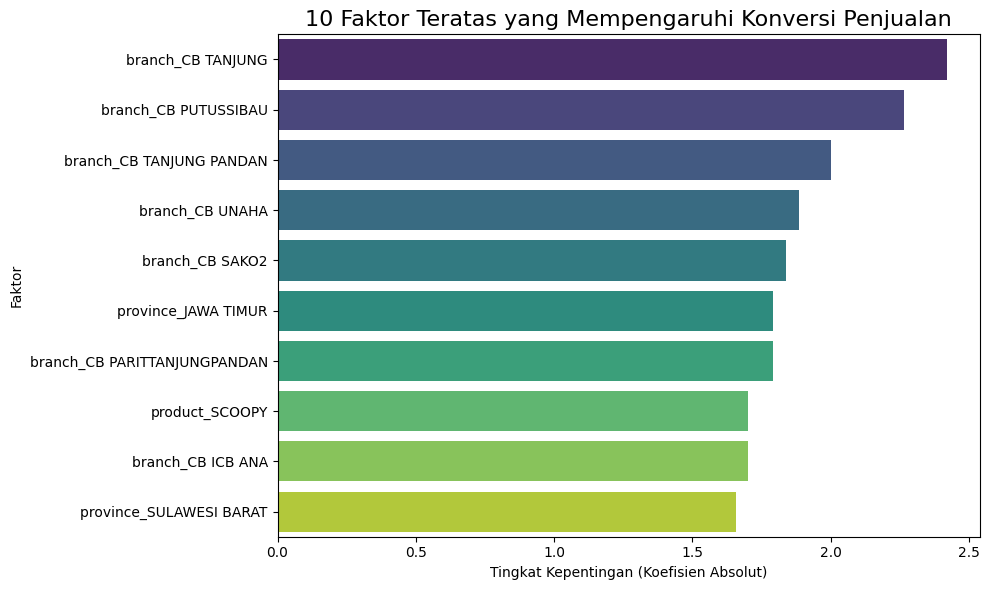

In [ ]:
# 1. Pemodelan Prediktif (Faktor Penentu Konversi)
# Membuat kolom target 'is_converted' untuk model prediksi
df['is_converted'] = np.where(df['sale_date'].notna(), 1, 0)

# Memilih fitur dan target
features = ['branch', 'province', 'product', 'payment', 'process']
target = 'is_converted'

# Mengatasi nilai yang hilang pada fitur kategorikal
analysis_df = df.copy() # Membuat salinan untuk analisis ini
for col in features:
    analysis_df[col].fillna('Unknown', inplace=True)

X = analysis_df[features]
y = analysis_df[target]

# Mengubah fitur kategorikal menjadi numerik dengan One-Hot Encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X)

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# Melatih model Regresi Logistik
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Memprediksi dan mengevaluasi model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Prediksi: {accuracy:.2%}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# Menemukan fitur paling berpengaruh
feature_names = encoder.get_feature_names_out(features)
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=False).head(10)

# Visualisasi fitur terpenting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('10 Faktor Teratas yang Mempengaruhi Konversi Penjualan', fontsize=16)
plt.xlabel('Tingkat Kepentingan (Koefisien Absolut)')
plt.ylabel('Faktor')
plt.tight_layout()
plt.show()

## Random Forest

Ukuran data latih: 8394 baris
Ukuran data uji: 2099 baris

Akurasi Model Random Forest: 0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1175
           1       0.71      0.66      0.68       924

    accuracy                           0.73      2099
   macro avg       0.72      0.72      0.72      2099
weighted avg       0.73      0.73      0.73      2099


Confusion Matrix:


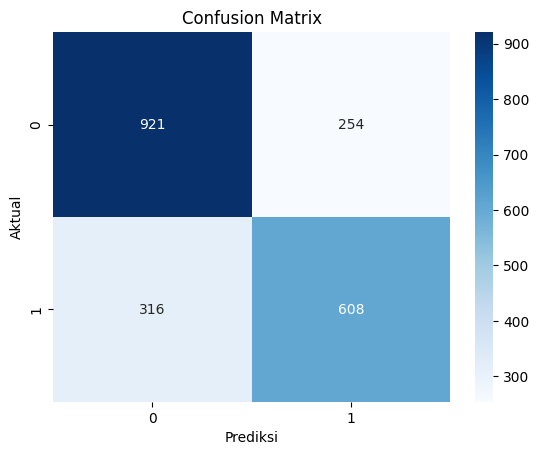

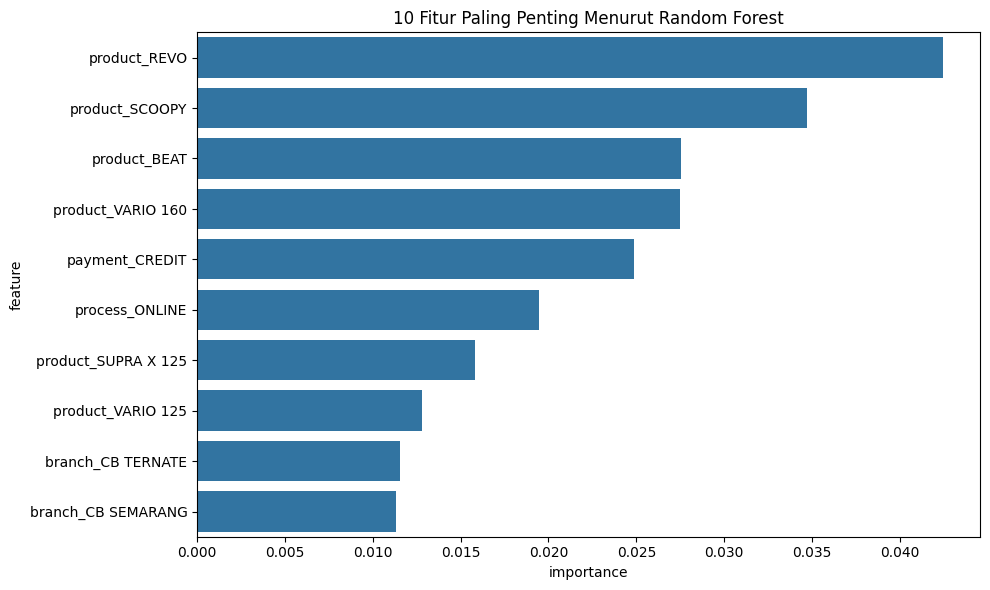

In [ ]:
# --- 1. Persiapan Data (Feature Engineering) ---

# Membuat variabel target 'converted'
# Jika 'sale_date' tidak kosong (NaT), berarti terjadi penjualan (1), jika kosong berarti tidak (0)
df['converted'] = df['sale_date'].notna().astype(int)

# Memilih fitur (X) dan target (y)
# Kita akan menggunakan variabel kategorikal sebagai fitur
features = ['branch', 'product', 'payment', 'process']
X = df[features]
y = df['converted']

# --- 2. Encoding Variabel Kategorikal ---
# Mengubah data kategorikal menjadi numerik menggunakan One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# --- 3. Membagi Data ---
# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran data latih: {X_train.shape[0]} baris")
print(f"Ukuran data uji: {X_test.shape[0]} baris")

# --- 4. Melatih Model Random Forest ---
# Membuat instance model
# n_estimators = jumlah pohon keputusan dalam "hutan"
# random_state = memastikan hasil yang sama setiap kali dijalankan
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Melatih model dengan data latih
rf_model.fit(X_train, y_train)

# --- 5. Evaluasi Model ---
# Membuat prediksi pada data uji
y_pred = rf_model.predict(X_test)

# Menghitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model Random Forest: {accuracy:.2f}")

# Menampilkan Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.savefig('confusion_matrix_rf.png')
plt.show()

# --- (Opsional) Melihat Feature Importance ---
importances = rf_model.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(10) # Ambil 10 teratas

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('10 Fitur Paling Penting Menurut Random Forest')
plt.tight_layout()
plt.savefig('feature_importance_rf.png')
plt.show()